#Renewble Energy Project

# import liabrary / Font

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'pandas'

In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import os

# Thai-capable font bundled with this project (fonts/Garuda.otf, from the TLWG font family,
# GPL-2+ with font exception — see fonts/GARUDA-LICENSE.txt). Works the same on Windows, Colab,
# or any classmate's machine as long as the 'fonts' folder travels next to this notebook —
# no apt-get/sudo needed.
FONT_PATH = os.path.join('fonts', 'Garuda.otf')

thai_font_name = None
if os.path.exists(FONT_PATH):
    fm.fontManager.addfont(FONT_PATH)
    thai_font_name = fm.FontProperties(fname=FONT_PATH).get_name()
else:
    # Fallback: a Thai-capable font already installed on this machine
    candidates = ['Garuda', 'Noto Sans Thai', 'Leelawadee UI', 'Leelawadee', 'Tahoma', 'Cordia New', 'Loma']
    installed = {f.name for f in fm.fontManager.ttflist}
    thai_font_name = next((c for c in candidates if c in installed), None)

if thai_font_name:
    plt.rcParams['font.family'] = thai_font_name
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.unicode_minus'] = False
    print(f'Thai font ready: "{thai_font_name}"')
else:
    print("No Thai font found. Make sure the 'fonts' folder (with Garuda.otf) "
          "sits next to this notebook.")

# Import file

In [ ]:
url = 'https://raw.githubusercontent.com/Manasafang/123/main/renewable_energy_countries_selected_v6.csv'
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
print(f"Countries: {df['country'].nunique()}")
print(f"Years: {df['year'].min()} – {df['year'].max()}")
df.head()

Shape: (5381, 22)
Countries: 213
Years: 2000 – 2025


,country,continent,year,iso_code,electricity_generation,renewables_share_elec,fossil_share_elec,low_carbon_share_elec,solar_electricity,wind_electricity,...,coal_electricity,gas_electricity,oil_electricity,other_renewable_electricity,solar_share_elec,wind_share_elec,hydro_share_elec,nuclear_share_elec,coal_share_elec,gas_share_elec
0,Afghanistan,Asia,2000,AFG,0.48,64.583,35.417,64.583,0.0,0.0,...,0.00,0.0,0.17,0.0,0.0,0.0,64.583,0.0,0.000,0.0
1,Afghanistan,Asia,2001,AFG,0.69,72.464,27.536,72.464,0.0,0.0,...,0.04,0.0,0.15,0.0,0.0,0.0,72.464,0.0,5.797,0.0
2,Afghanistan,Asia,2002,AFG,0.71,78.873,21.127,78.873,0.0,0.0,...,0.04,0.0,0.11,0.0,0.0,0.0,78.873,0.0,5.634,0.0
3,Afghanistan,Asia,2003,AFG,0.91,69.231,30.769,69.231,0.0,0.0,...,0.09,0.0,0.19,0.0,0.0,0.0,69.231,0.0,9.890,0.0
4,Afghanistan,Asia,2004,AFG,0.79,70.886,29.114,70.886,0.0,0.0,...,0.06,0.0,0.17,0.0,0.0,0.0,70.886,0.0,7.595,0.0


#Act 1 The Rise

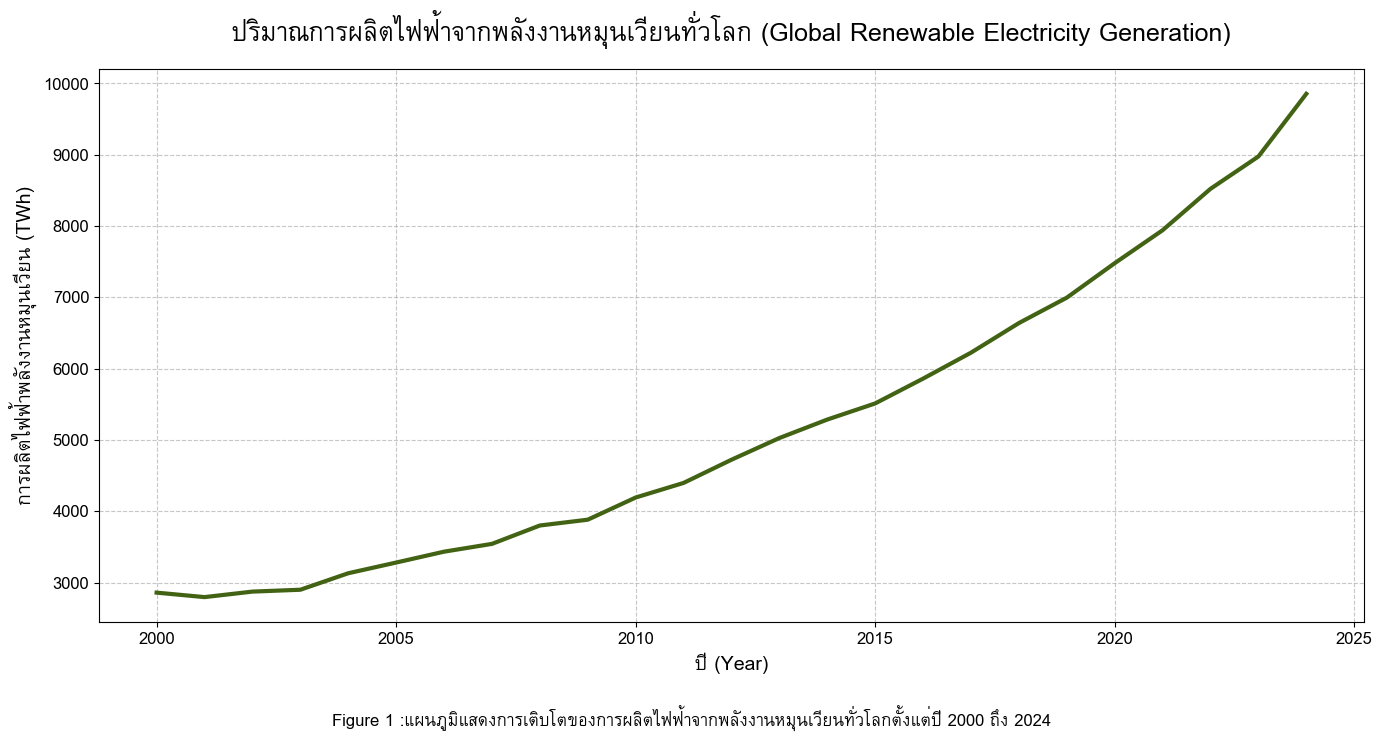

In [ ]:
df_filtered = df[df['year'] < 2025]
df_filtered['renewable_electricity_TWh'] = df_filtered['electricity_generation'] * (df_filtered['renewables_share_elec'] / 100)

global_renewable_generation = df_filtered.groupby('year')['renewable_electricity_TWh'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='year', y='renewable_electricity_TWh', data=global_renewable_generation, color='#426214', linewidth=3)

plt.title('ปริมาณการผลิตไฟฟ้าจากพลังงานหมุนเวียนทั่วโลก (Global Renewable Electricity Generation)', fontsize=18, pad=20)
plt.xlabel('ปี (Year)', fontsize=14)
plt.ylabel('การผลิตไฟฟ้าพลังงานหมุนเวียน (TWh)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ticklabel_format(style='plain', axis='y')

plt.locator_params(axis='x', nbins=10)

# Adding description text below the plot
description_text = 'Figure 1 :แผนภูมิแสดงการเติบโตของการผลิตไฟฟ้าจากพลังงานหมุนเวียนทั่วโลกตั้งแต่ปี 2000 ถึง 2024'
plt.figtext(0.5, -0.05, description_text, wrap=True, horizontalalignment='center', fontsize=12, color='black')

plt.tight_layout()
plt.show()

### แผนภูมิแสดงสัดส่วนการผลิตไฟฟ้าทั่วโลกตามประเภทพลังงาน (Global Electricity Generation Share by Energy Type)

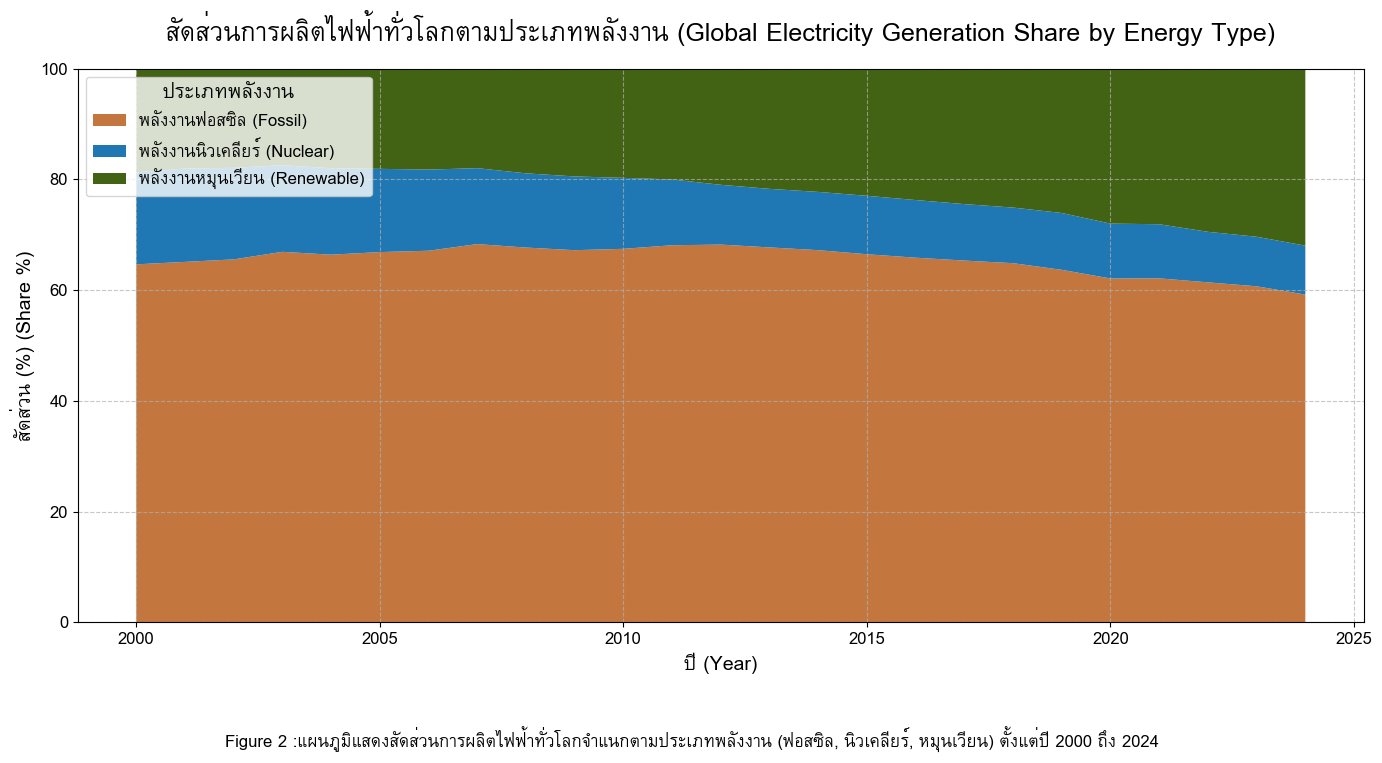

In [ ]:
df_filtered = df[df['year'] < 2025]
df_filtered['renewable_electricity_TWh'] = df_filtered['electricity_generation'] * (df_filtered['renewables_share_elec'] / 100)

# Assuming df_filtered is available from the previous cell and contains 'renewable_electricity_TWh'
df_plot_shares = df_filtered.copy()

# Calculate total generation for fossil and nuclear based on their share
df_plot_shares['fossil_electricity_TWh'] = df_plot_shares['electricity_generation'] * (df_plot_shares['fossil_share_elec'] / 100)
df_plot_shares['nuclear_electricity_TWh'] = df_plot_shares['electricity_generation'] * (df_plot_shares['nuclear_share_elec'] / 100)

# Aggregate global totals per year for each energy type
global_generation_by_type = df_plot_shares.groupby('year').agg(
    total_renewable_TWh=('renewable_electricity_TWh', 'sum'),
    total_fossil_TWh=('fossil_electricity_TWh', 'sum'),
    total_nuclear_TWh=('nuclear_electricity_TWh', 'sum'),
    total_electricity_TWh=('electricity_generation', 'sum') # Sum of total electricity generation for global denominator
).reset_index()

# Calculate global percentage share for each type
global_generation_by_type['renewable_share'] = (global_generation_by_type['total_renewable_TWh'] / global_generation_by_type['total_electricity_TWh']) * 100
global_generation_by_type['fossil_share'] = (global_generation_by_type['total_fossil_TWh'] / global_generation_by_type['total_electricity_TWh']) * 100
global_generation_by_type['nuclear_share'] = (global_generation_by_type['total_nuclear_TWh'] / global_generation_by_type['total_electricity_TWh']) * 100


# Define colors for the plot
colors = {
    'พลังงานหมุนเวียน (Renewable)': '#426214',  # Dark green
    'พลังงานฟอสซิล (Fossil)': '#C3773F',      # Custom Brownish/Orange
    'พลังงานนิวเคลียร์ (Nuclear)': '#1f77b4'   # Blue
}

plt.figure(figsize=(14, 7))

# Create the stacked area chart with the new order: Fossil, Nuclear, Renewable
plt.stackplot(global_generation_by_type['year'],
              global_generation_by_type['fossil_share'],   # Fossil at the bottom
              global_generation_by_type['nuclear_share'],  # Nuclear in the middle
              global_generation_by_type['renewable_share'],# Renewable on top
              labels=['พลังงานฟอสซิล (Fossil)', 'พลังงานนิวเคลียร์ (Nuclear)', 'พลังงานหมุนเวียน (Renewable)'],
              colors=[colors['พลังงานฟอสซิล (Fossil)'], colors['พลังงานนิวเคลียร์ (Nuclear)'], colors['พลังงานหมุนเวียน (Renewable)']])

plt.title('สัดส่วนการผลิตไฟฟ้าทั่วโลกตามประเภทพลังงาน (Global Electricity Generation Share by Energy Type)', fontsize=18, pad=20)
plt.xlabel('ปี (Year)', fontsize=14)
plt.ylabel('สัดส่วน (%) (Share %)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100%
plt.legend(title='ประเภทพลังงาน', loc='upper left', fontsize=12, title_fontsize='14')

plt.locator_params(axis='x', nbins=10) # Adjust x-axis ticks

# Adding description text below the plot (updated order and text)
description_text = 'Figure 2 :แผนภูมิแสดงสัดส่วนการผลิตไฟฟ้าทั่วโลกจำแนกตามประเภทพลังงาน (ฟอสซิล, นิวเคลียร์, หมุนเวียน) ตั้งแต่ปี 2000 ถึง 2024'
plt.figtext(0.5, -0.08, description_text, wrap=True, horizontalalignment='center', fontsize=12, color='black')

plt.tight_layout()
plt.show()

# Chat Mode 💬

Ask questions about the renewable energy dataset in plain language (English or Thai) through an actual chat page (no terminal prompts). Claude turns each question into pandas/matplotlib code, runs it against `df` / `df_filtered`, and the chat page shows the answer text plus the latest chart. Follow-up questions ("what about wind?") keep context from earlier turns in the same session.

In [ ]:
import getpass

try:
    import anthropic
except ImportError:
    !pip install -q anthropic
    import anthropic

try:
    import gradio as gr
except ImportError:
    !pip install -q gradio
    import gradio as gr

anthropic_api_key = getpass.getpass("Enter your Anthropic API key: ")
chat_client = anthropic.Anthropic(api_key=anthropic_api_key)
CHAT_MODEL = "claude-sonnet-5"

In [ ]:
import io
from PIL import Image

DATA_CONTEXT = f"""You are a data analyst assistant answering questions about a renewable energy dataset.

Two DataFrames are available in the running Python session:

`df` (raw data), columns and dtypes:
{df.dtypes.to_string()}
Shape: {df.shape}

`df_filtered` = df[df['year'] < 2025], with an added 'renewable_electricity_TWh' column
(electricity_generation * renewables_share_elec / 100). Same columns as df plus that one.

Sample rows from df:
{df.head(3).to_string()}

pandas as pd, numpy as np, matplotlib.pyplot as plt, and seaborn as sns are already imported
and configured (Thai-capable font).

Reply with ONLY a single fenced ```python code block, nothing else. The code must assign the
answer to a variable named `result`:
- For a number/string/list answer: assign that value to `result`.
- For a table answer: assign a DataFrame/Series to `result`.
- For a chart request: draw the chart with plt/sns (do not call plt.show()), and set
  result = "chart displayed below".
Never modify `df` or `df_filtered` in place; use .copy() if you need to transform data.
"""

chat_history = []

def run_chat_turn(question):
    """Send `question` to Claude, run the generated code, return (code, answer_text, chart_image)."""
    chat_history.append({"role": "user", "content": question})
    response = chat_client.messages.create(
        model=CHAT_MODEL,
        max_tokens=1024,
        system=DATA_CONTEXT,
        messages=chat_history[-10:],
    )
    reply_text = response.content[0].text
    chat_history.append({"role": "assistant", "content": reply_text})

    if "```python" in reply_text:
        code = reply_text.split("```python", 1)[1].split("```", 1)[0]
    elif "```" in reply_text:
        code = reply_text.split("```", 1)[1].split("```", 1)[0]
    else:
        code = reply_text
    code = code.strip()

    plt.close("all")
    local_ns = {"df": df, "df_filtered": df_filtered, "pd": pd, "np": np, "plt": plt, "sns": sns}
    chart_image = None
    try:
        exec(code, {}, local_ns)
        result = local_ns.get("result")
        if plt.get_fignums():
            buf = io.BytesIO()
            plt.savefig(buf, format="png", bbox_inches="tight")
            plt.close("all")
            buf.seek(0)
            chart_image = Image.open(buf)
        answer_text = "" if result is None else str(result)
    except Exception as e:
        answer_text = f"Error running generated code: {e}"

    return code, answer_text, chart_image

In [ ]:
def bot_respond(message, history):
    message = (message or "").strip()
    if not message:
        return history, None, "", ""

    code, answer_text, chart_image = run_chat_turn(message)
    history = (history or []) + [
        {"role": "user", "content": message},
        {"role": "assistant", "content": answer_text or "(see chart below)"},
    ]
    return history, chart_image, code, ""

with gr.Blocks(title="Renewable Energy Chat") as chat_page:
    gr.Markdown("## 💬 Ask the Renewable Energy Dataset")
    chatbot = gr.Chatbot(type="messages", height=420)
    with gr.Row():
        msg = gr.Textbox(
            placeholder="Ask a question... e.g. 'top 5 solar producers in 2023'",
            scale=4, show_label=False,
        )
        send_btn = gr.Button("Send", scale=1)
    chart_output = gr.Image(label="Latest chart")
    with gr.Accordion("Generated code", open=False):
        code_output = gr.Code(language="python")

    send_btn.click(bot_respond, inputs=[msg, chatbot], outputs=[chatbot, chart_output, code_output, msg])
    msg.submit(bot_respond, inputs=[msg, chatbot], outputs=[chatbot, chart_output, code_output, msg])

chat_page.launch(inline=True, share=False)